In [211]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [212]:
df=pd.read_csv('Churn_Modelling.csv')

In [213]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [214]:
df.sample()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
4067,4068,15767391,Otutodilinna,565,Germany,Female,32,4,90322.99,2,0,1,118740.37,0


In [215]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [216]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [217]:
(df['Tenure'] > 7).sum() / len(df) * 100

np.float64(24.990000000000002)

In [218]:
df.shape

(10000, 14)

In [219]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [220]:
df.duplicated().sum()

np.int64(0)

In [221]:
df.sample()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
2662,2663,15742272,Ozerova,669,France,Female,44,8,96418.09,1,0,0,131609.48,1


In [223]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

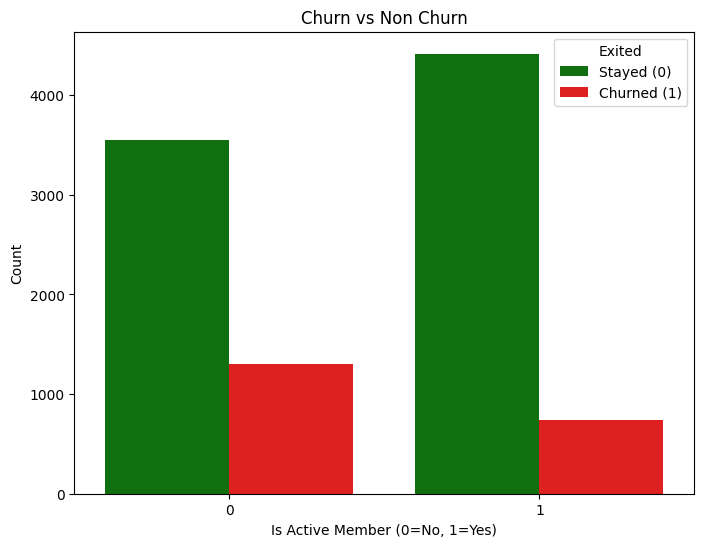

In [224]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='IsActiveMember', hue='Exited', 
              palette=['green', 'red'])

plt.xlabel('Is Active Member (0=No, 1=Yes)')
plt.ylabel('Count')
plt.title('Churn vs Non Churn')
plt.legend(title='Exited', labels=['Stayed (0)', 'Churned (1)'])
plt.show()

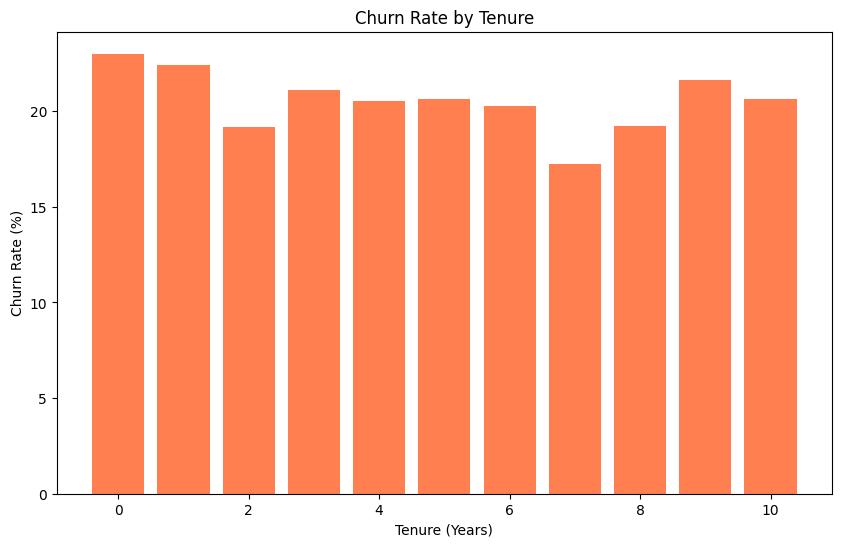

In [225]:
plt.figure(figsize=(10, 6))
churn_rate = df.groupby('Tenure')['Exited'].mean() * 100

plt.bar(churn_rate.index, churn_rate.values, color='coral')
plt.xlabel('Tenure (Years)')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Tenure')
plt.show()

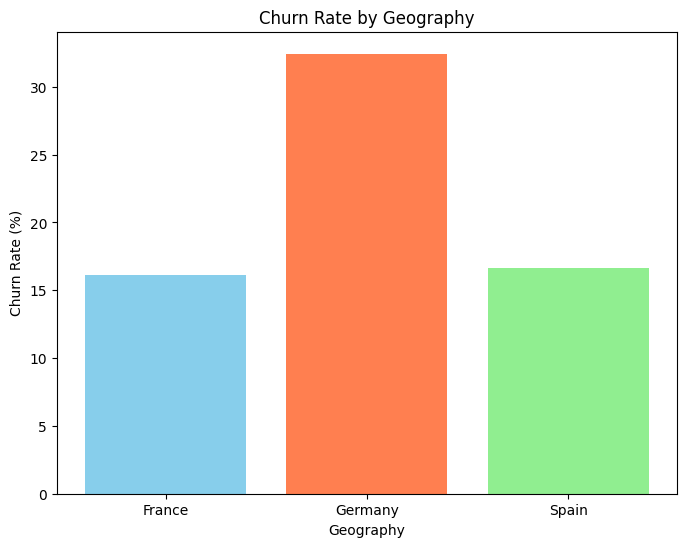

In [226]:
plt.figure(figsize=(8, 6))
churn_rate = df.groupby('Geography')['Exited'].mean() * 100

plt.bar(churn_rate.index, churn_rate.values, color=['skyblue', 'coral', 'lightgreen'])
plt.xlabel('Geography')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Geography')
plt.show()

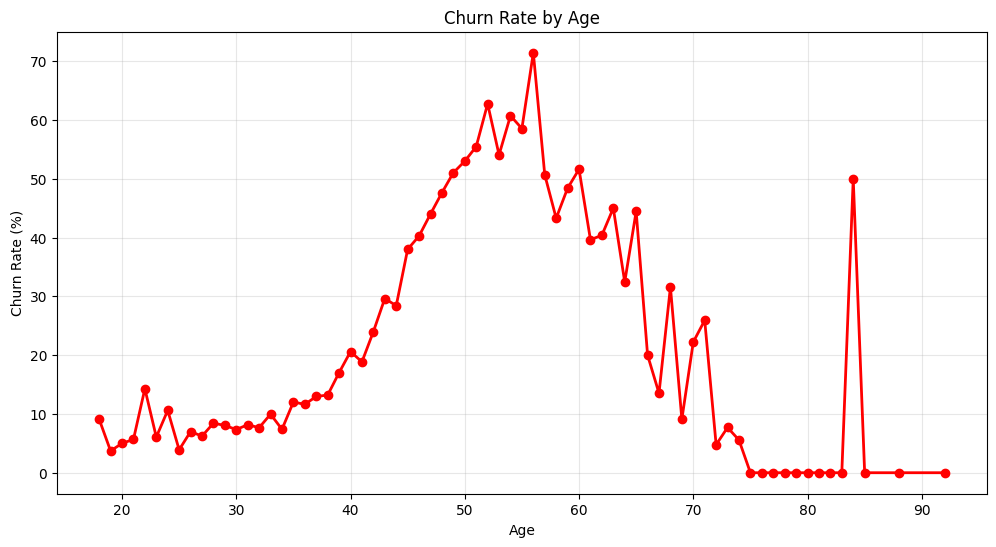

In [227]:
plt.figure(figsize=(12, 6))
churn_rate = df.groupby('Age')['Exited'].mean() * 100

plt.plot(churn_rate.index, churn_rate.values, marker='o', 
         linewidth=2, markersize=6, color='red')
plt.xlabel('Age')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Age')
plt.grid(True, alpha=0.3)
plt.show()

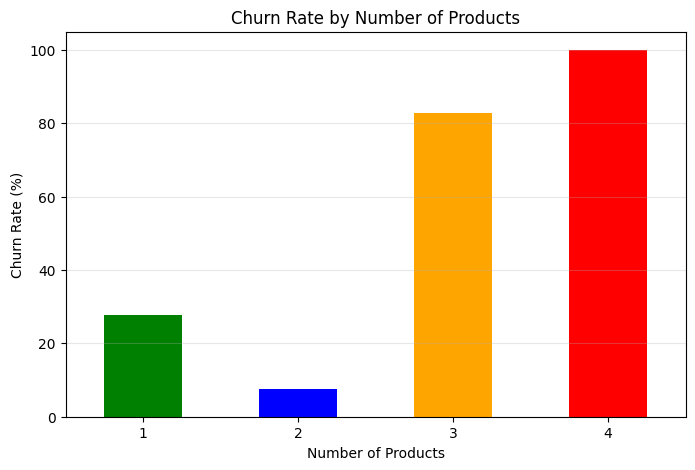

NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64


In [228]:
# Churn rate by NumOfProducts
churn_by_products = df.groupby('NumOfProducts')['Exited'].mean() * 100

plt.figure(figsize=(8, 5))
churn_by_products.plot(kind='bar', color=['green', 'blue', 'orange', 'red'])
plt.title('Churn Rate by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

print(churn_by_products)

In [229]:
df['NumOfProducts'].value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [230]:
df.sample()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
759,760,15625944,Buccho,664,France,Male,58,5,98668.18,1,1,1,60887.58,0


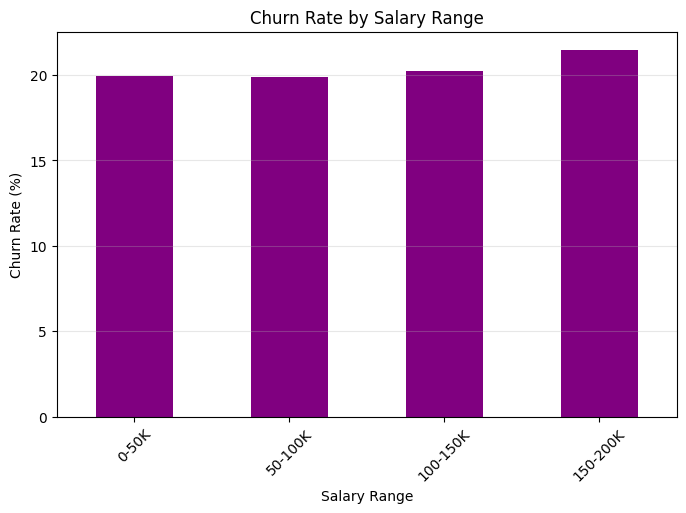

SalaryBin
0-50K       19.934774
50-100K     19.865983
100-150K    20.234834
150-200K    21.466395
Name: Exited, dtype: float64


In [231]:
# Create salary bins
df['SalaryBin'] = pd.cut(df['EstimatedSalary'], 
                         bins=[0, 50000, 100000, 150000, 200000],
                         labels=['0-50K', '50-100K', '100-150K', '150-200K'])

# Churn rate by salary
churn_by_salary = df.groupby('SalaryBin')['Exited'].mean() * 100

plt.figure(figsize=(8, 5))
churn_by_salary.plot(kind='bar', color='purple')
plt.title('Churn Rate by Salary Range')
plt.xlabel('Salary Range')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

print(churn_by_salary)

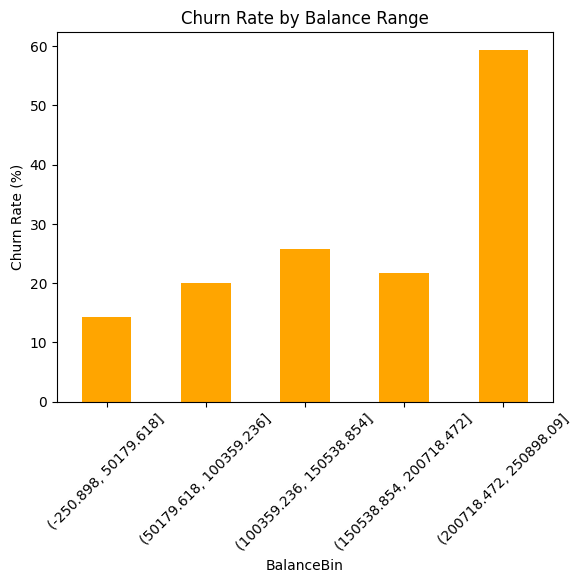

In [232]:
df['BalanceBin'] = pd.cut(df['Balance'], bins=5)
churn_by_balance = df.groupby('BalanceBin')['Exited'].mean() * 100
churn_by_balance.plot(kind='bar', color='orange')
plt.title('Churn Rate by Balance Range')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

                       mean  count  churn_rate_%
CreditScore_Range                               
<400               1.000000     19    100.000000
400-500            0.213141    624     21.314103
500-600            0.211721   2423     21.172101
600-700            0.197224   3818     19.722368
700+               0.198652   3116     19.865212


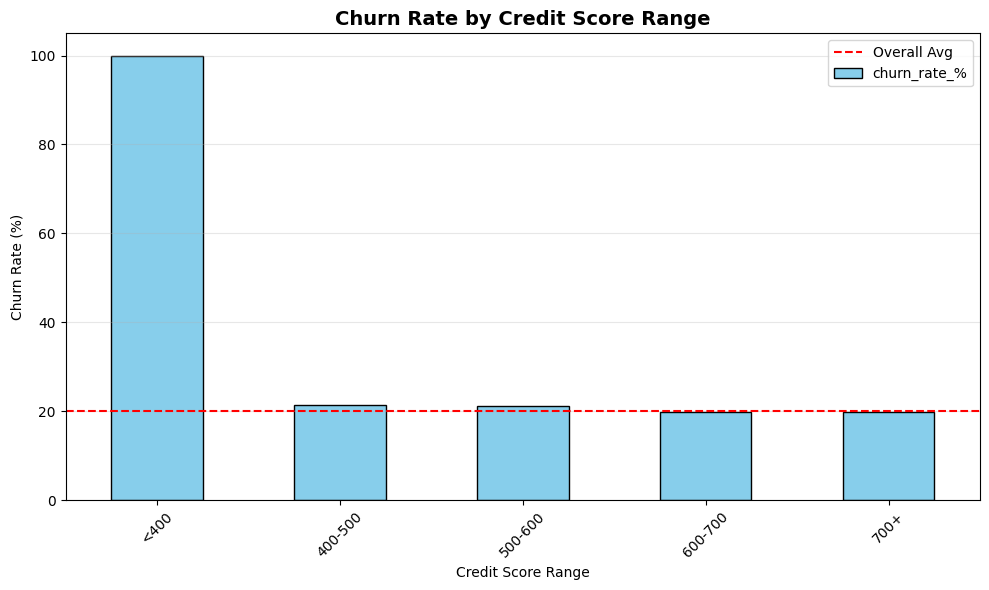

In [233]:
# Step 1: Create credit score ranges
df['CreditScore_Range'] = pd.cut(df['CreditScore'], 
                                   bins=[0, 400, 500, 600, 700, 850],
                                   labels=['<400', '400-500', '500-600', '600-700', '700+'])

# Step 2: Calculate churn rate
churn_by_credit = df.groupby('CreditScore_Range')['Exited'].agg(['mean', 'count'])
churn_by_credit['churn_rate_%'] = churn_by_credit['mean'] * 100

print(churn_by_credit)

# Step 3: Visualize
plt.figure(figsize=(10, 6))
churn_by_credit['churn_rate_%'].plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Churn Rate by Credit Score Range', fontsize=14, fontweight='bold')
plt.xlabel('Credit Score Range')
plt.ylabel('Churn Rate (%)')
plt.axhline(y=20, color='red', linestyle='--', label='Overall Avg')
plt.legend()
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [234]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'SalaryBin',
       'BalanceBin', 'CreditScore_Range'],
      dtype='str')

In [244]:
df = df.drop(columns=['RowNumber','CustomerId'])

In [255]:
# Before train_test_split
df = df.drop(columns=['Surname', 'SalaryBin', 'BalanceBin', 'CreditScore_Range'])

In [256]:
# X = all columns EXCEPT 'Exited'
X = df.drop('Exited', axis=1)

# y = only 'Exited' column
y = df['Exited']

# Check shapes
print(X.shape)  # (rows, features)
print(y.shape)  # (rows,)

(10000, 10)
(10000,)


In [257]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [258]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(8000, 10) (2000, 10)
(8000,) (2000,)


In [259]:
# Numeric columns (no encoding needed)
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance',
                    'NumOfProducts', 'HasCrCard', 'IsActiveMember', 
                    'EstimatedSalary']

# Categorical column (needs OneHotEncoder)
categorical_features = ['Geography', 'Gender']

In [260]:
print(le.classes_)  # Shows ['Female', 'Male'] or ['Male', 'Female']

['Female' 'Male']


In [261]:
print(X_train['Gender'].unique())

<StringArray>
['Male', 'Female']
Length: 2, dtype: str


In [262]:
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Categorical: ['Geography', 'Gender']


In [263]:
print(X_train.columns.tolist())

['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [264]:
print("Columns in X_train:")
print(X_train.columns.tolist())

Columns in X_train:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [265]:
all_features = numeric_features + categorical_features
missing = set(X_train.columns) - set(all_features)
print("Missing features:", missing) 

Missing features: set()


In [266]:
X_train = X_train[numeric_features + categorical_features]
X_test = X_test[numeric_features + categorical_features]

In [267]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Numeric Transformer (scales numbers)
numeric_transformer = StandardScaler()

# 2. Categorical Transformer (one-hot encodes)
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False)

# 3. Combine both with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [268]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(random_state=42, max_iter=1000)

In [269]:
from sklearn.pipeline import Pipeline

# Create the pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

print(pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Geography', 'Gender'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])


In [270]:
X_train

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography,Gender
9254,686,32,6,0.00,2,1,1,179093.26,France,Male
1561,632,42,4,119624.60,2,1,1,195978.86,Germany,Male
1670,559,24,3,114739.92,1,1,0,85891.02,Spain,Male
6087,561,27,9,135637.00,1,1,0,153080.40,France,Female
6669,517,56,9,142147.32,1,0,0,39488.04,France,Male
...,...,...,...,...,...,...,...,...,...,...
5734,768,54,8,69712.74,1,1,1,69381.05,France,Male
5191,682,58,1,0.00,1,1,1,706.50,France,Female
5390,735,38,1,0.00,3,0,0,92220.12,France,Female
860,667,43,8,190227.46,1,1,0,97508.04,France,Male


In [271]:
pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [272]:
# Predict on test data
y_pred = pipeline.predict(X_test)

print(f"First 10 predictions: {y_pred[:10]}")
print(f"First 10 actual values: {y_test[:10].values}")

First 10 predictions: [0 0 0 0 0 0 0 0 0 0]
First 10 actual values: [0 0 0 0 0 0 0 1 0 0]


In [273]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [274]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [275]:
from sklearn.metrics import accuracy_score

In [276]:
accuracy_score(y_test, y_pred)

0.811

In [277]:
from sklearn.ensemble import RandomForestClassifier

In [278]:
model=RandomForestClassifier()

In [279]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

In [280]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [281]:
y_pred=pipeline.predict(X_test)

In [282]:
y_pred

array([0, 0, 0, ..., 1, 0, 0], shape=(2000,))

In [283]:
accuracy_score(y_test, y_pred)

0.8675

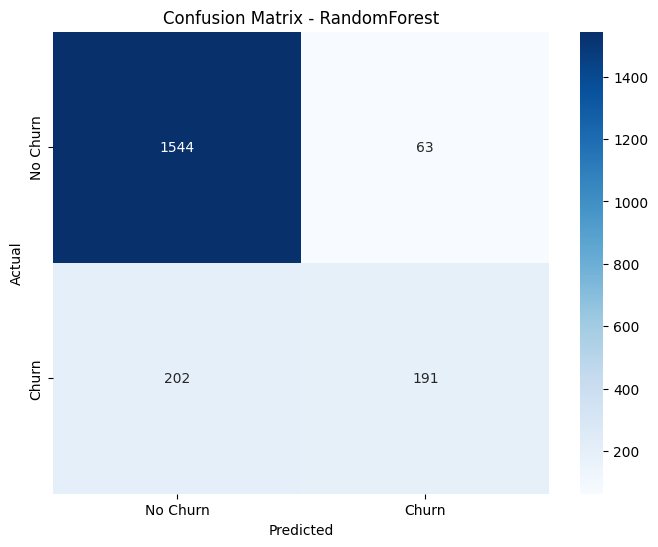

Confusion Matrix:
[[1544   63]
 [ 202  191]]


In [284]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - RandomForest')
plt.show()

# Print the matrix
print("Confusion Matrix:")
print(cm)

In [285]:
from sklearn.metrics import classification_report

# Generate Classification Report
print("📊 CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.88      0.96      0.92      1607
       Churn       0.75      0.49      0.59       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [286]:
from sklearn.metrics import roc_auc_score

# Calculate ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred)

print("📈 ROC-AUC SCORE")
print("="*60)
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("="*60)

# Interpretation
if roc_auc >= 0.9:
    print("🌟 EXCELLENT! Outstanding model performance!")
elif roc_auc >= 0.8:
    print("✅ VERY GOOD! Strong model performance!")
elif roc_auc >= 0.7:
    print("👍 GOOD! Acceptable model performance!")
elif roc_auc >= 0.6:
    print("⚠️ FAIR! Needs improvement!")
else:
    print("❌ POOR! Model needs serious work!")

📈 ROC-AUC SCORE
ROC-AUC Score: 0.7234
👍 GOOD! Acceptable model performance!


In [288]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Extract your existing preprocessor from the pipeline
preprocessor = pipeline.named_steps['preprocessor']

# Create TWO separate pipelines with same preprocessor
pipelines = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
    ])
}

# Store results
results = []
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print("🔄 Running Cross-Validation...\n")

# Compare both models
for model_name, model_pipeline in pipelines.items():
    print(f"Training {model_name}...")
    
    # Cross-validation (5-fold)
    cv_scores = cross_validate(model_pipeline, X_train, y_train, cv=5, scoring=scoring)
    
    # Train on full data
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]
    
    # Store metrics
    results.append({
        'Model': model_name,
        'CV_Accuracy': cv_scores['test_accuracy'].mean(),
        'CV_Precision': cv_scores['test_precision'].mean(),
        'CV_Recall': cv_scores['test_recall'].mean(),
        'CV_F1': cv_scores['test_f1'].mean(),
        'CV_ROC_AUC': cv_scores['test_roc_auc'].mean(),
        'Test_Accuracy': accuracy_score(y_test, y_pred),
        'Test_Precision': precision_score(y_test, y_pred),
        'Test_Recall': recall_score(y_test, y_pred),
        'Test_F1': f1_score(y_test, y_pred),
        'Test_ROC_AUC': roc_auc_score(y_test, y_pred_proba)
    })

# Create comparison table
comparison_df = pd.DataFrame(results)

print("\n" + "="*90)
print("📊 MODEL COMPARISON TABLE")
print("="*90)
print(comparison_df.round(4).to_string(index=False))
print("="*90)

# Best model
best_idx = comparison_df['CV_ROC_AUC'].idxmax()
best_name = comparison_df.loc[best_idx, 'Model']
print(f"\n✅ Best Model: {best_name} (CV ROC-AUC: {comparison_df.loc[best_idx, 'CV_ROC_AUC']:.4f})")

🔄 Running Cross-Validation...

Training Logistic Regression...
Training Random Forest...

📊 MODEL COMPARISON TABLE
              Model  CV_Accuracy  CV_Precision  CV_Recall  CV_F1  CV_ROC_AUC  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  Test_ROC_AUC
Logistic Regression       0.8104        0.6088     0.2178 0.3194      0.7619         0.8110          0.5524       0.2010   0.2948        0.7789
      Random Forest       0.8614        0.7708     0.4659 0.5795      0.8523         0.8665          0.7625       0.4656   0.5782        0.8653

✅ Best Model: Random Forest (CV ROC-AUC: 0.8523)


In [289]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import numpy as np

print("🔧 Starting Hyperparameter Tuning...\n")

# Extract preprocessor
preprocessor = pipeline.named_steps['preprocessor']

# Create RF pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Parameter distributions
param_distributions = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [10, 20, 30, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__class_weight': ['balanced', None]
}

# RandomizedSearchCV (faster than GridSearchCV)
random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_distributions,
    n_iter=50,  # 50 random combinations
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,  # Use all CPU cores
    random_state=42,
    verbose=2
)

# Fit
random_search.fit(X_train, y_train)

# Best model
best_model = random_search.best_estimator_

print("\n" + "="*70)
print("🏆 BEST PARAMETERS FOUND:")
print("="*70)
for param, value in random_search.best_params_.items():
    print(f"{param.replace('classifier__', '')}: {value}")

print("\n" + "="*70)
print("📈 PERFORMANCE COMPARISON:")
print("="*70)
print(f"Before Tuning (CV ROC-AUC): 0.8523")
print(f"After Tuning (CV ROC-AUC):  {random_search.best_score_:.4f}")
print(f"Improvement: {(random_search.best_score_ - 0.8523):.4f}")

# Test set evaluation
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

test_roc_auc = roc_auc_score(y_test, y_pred_proba)
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

print("\n" + "="*70)
print("🎯 TEST SET PERFORMANCE (Tuned Model):")
print("="*70)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("="*70)

🔧 Starting Hyperparameter Tuning...

Fitting 5 folds for each of 50 candidates, totalling 250 fits

🏆 BEST PARAMETERS FOUND:
n_estimators: 500
min_samples_split: 5
min_samples_leaf: 2
max_features: log2
max_depth: 10
class_weight: balanced

📈 PERFORMANCE COMPARISON:
Before Tuning (CV ROC-AUC): 0.8523
After Tuning (CV ROC-AUC):  0.8628
Improvement: 0.0105

🎯 TEST SET PERFORMANCE (Tuned Model):
Accuracy:  0.8445
Precision: 0.5891
Recall:    0.6896
F1 Score:  0.6354
ROC-AUC:   0.8695


🔍 Extracting Feature Importance...

🏆 TOP 15 MOST IMPORTANT FEATURES:
               Feature  Importance
              num__Age    0.326631
    num__NumOfProducts    0.213372
          num__Balance    0.117105
  num__EstimatedSalary    0.078000
      num__CreditScore    0.075630
   num__IsActiveMember    0.056676
cat__Geography_Germany    0.046775
           num__Tenure    0.042550
      cat__Gender_Male    0.023473
        num__HasCrCard    0.010053
  cat__Geography_Spain    0.009734


C:\Users\6077108\AppData\Local\Temp\ipykernel_14648\3731079950.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_15, y='Feature', x='Importance', palette='viridis')


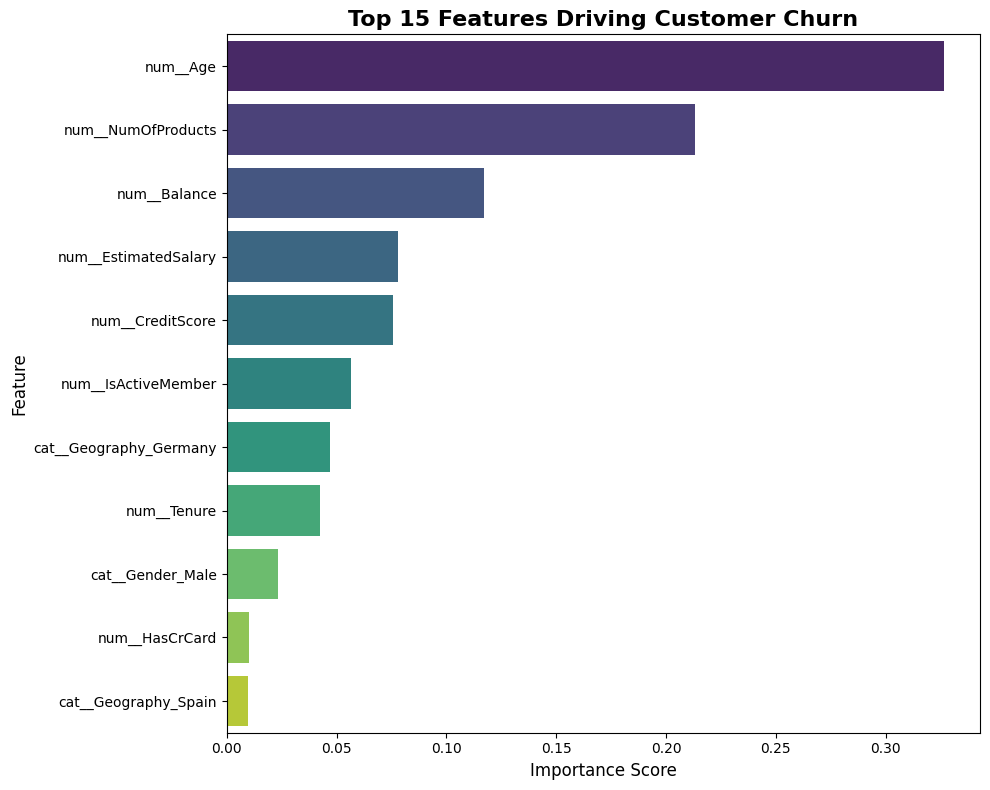


✅ Feature importance plot saved as 'feature_importance.png'

📊 FEATURE IMPORTANCE BY CATEGORY:

Tenure: 0.0426 (Total Importance)
  - num__Tenure: 0.0426

Demographics: 0.0235 (Total Importance)
  - cat__Gender_Male: 0.0235



In [290]:
print("🔍 Extracting Feature Importance...\n")

# Get the classifier from best_model
rf_classifier = best_model.named_steps['classifier']

# Get feature names after preprocessing
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Get feature importances
importances = rf_classifier.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Top 15 features
top_15 = feature_importance_df.head(15)

print("="*70)
print("🏆 TOP 15 MOST IMPORTANT FEATURES:")
print("="*70)
print(top_15.to_string(index=False))
print("="*70)

# Visualization
plt.figure(figsize=(10, 8))
sns.barplot(data=top_15, y='Feature', x='Importance', palette='viridis')
plt.title('Top 15 Features Driving Customer Churn', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Feature importance plot saved as 'feature_importance.png'")

# Group by feature categories
print("\n" + "="*70)
print("📊 FEATURE IMPORTANCE BY CATEGORY:")
print("="*70)

# Extract original feature names (before encoding)
categories = {
    'Tenure': [],
    'Contract': [],
    'Services': [],
    'Demographics': [],
    'Charges': []
}

for idx, row in top_15.iterrows():
    feat = row['Feature']
    imp = row['Importance']
    
    if 'tenure' in feat.lower():
        categories['Tenure'].append((feat, imp))
    elif 'contract' in feat.lower():
        categories['Contract'].append((feat, imp))
    elif any(x in feat.lower() for x in ['service', 'internet', 'phone', 'security', 'backup', 'protection', 'support', 'streaming']):
        categories['Services'].append((feat, imp))
    elif any(x in feat.lower() for x in ['gender', 'senior', 'partner', 'dependent']):
        categories['Demographics'].append((feat, imp))
    elif any(x in feat.lower() for x in ['charge', 'monthly', 'total']):
        categories['Charges'].append((feat, imp))

for category, features in categories.items():
    if features:
        total_imp = sum([f[1] for f in features])
        print(f"\n{category}: {total_imp:.4f} (Total Importance)")
        for feat, imp in features:
            print(f"  - {feat}: {imp:.4f}")

print("\n" + "="*70)

In [291]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

print("💼 GENERATING BUSINESS OUTPUTS...\n")

# Get churn probabilities for test set
churn_probabilities = best_model.predict_proba(X_test)[:, 1]

# Create business output DataFrame
business_output = pd.DataFrame({
    'Actual_Churn': y_test,
    'Churn_Probability': churn_probabilities
})

# Add predictions with default threshold (0.5)
business_output['Predicted_Churn_50'] = (churn_probabilities >= 0.5).astype(int)

# Risk Segmentation
def risk_segment(prob):
    if prob >= 0.7:
        return 'High Risk'
    elif prob >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

business_output['Risk_Segment'] = business_output['Churn_Probability'].apply(risk_segment)

print("="*70)
print("📊 CUSTOMER RISK SEGMENTATION:")
print("="*70)
print(business_output['Risk_Segment'].value_counts())
print()

# Show sample customers
print("="*70)
print("👥 SAMPLE CUSTOMERS (Sorted by Churn Risk):")
print("="*70)
print(business_output.sort_values('Churn_Probability', ascending=False).head(10).to_string(index=False))

# Test different thresholds
print("\n" + "="*70)
print("🎯 IMPACT OF DECISION THRESHOLDS:")
print("="*70)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (churn_probabilities >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    threshold_results.append({
        'Threshold': threshold,
        'True_Positives': tp,
        'False_Positives': fp,
        'False_Negatives': fn,
        'Precision': precision,
        'Recall': recall,
        'Customers_Flagged': tp + fp
    })

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df.to_string(index=False))

print("\n" + "="*70)
print("💡 BUSINESS INTERPRETATION:")
print("="*70)
print("Threshold 0.3: Contact MORE customers (higher recall), more false alarms")
print("Threshold 0.5: BALANCED approach")
print("Threshold 0.7: Contact FEWER customers (higher precision), miss some churners")

# Recommended action
print("\n" + "="*70)
print("✅ RECOMMENDED THRESHOLD FOR BUSINESS:")
print("="*70)

# Find threshold with best F1 or based on business need
best_threshold_idx = threshold_df['Recall'].idxmax()  # Prioritize catching churners
recommended = threshold_df.iloc[best_threshold_idx]

print(f"Threshold: {recommended['Threshold']}")
print(f"Will flag {int(recommended['Customers_Flagged'])} customers")
print(f"Catch {recommended['Recall']:.1%} of actual churners")
print(f"Precision: {recommended['Precision']:.1%} (accuracy of flagged customers)")
print("="*70)

# Save business output
business_output.to_csv('churn_predictions.csv', index=False)
print("\n✅ Predictions saved as 'churn_predictions.csv'")

💼 GENERATING BUSINESS OUTPUTS...

📊 CUSTOMER RISK SEGMENTATION:
Risk_Segment
Low Risk       1359
Medium Risk     421
High Risk       220
Name: count, dtype: int64

👥 SAMPLE CUSTOMERS (Sorted by Churn Risk):
 Actual_Churn  Churn_Probability  Predicted_Churn_50 Risk_Segment
            1           0.971229                   1    High Risk
            1           0.971096                   1    High Risk
            1           0.954414                   1    High Risk
            1           0.948630                   1    High Risk
            1           0.943508                   1    High Risk
            0           0.942094                   1    High Risk
            1           0.941841                   1    High Risk
            1           0.940303                   1    High Risk
            1           0.940282                   1    High Risk
            1           0.933953                   1    High Risk

🎯 IMPACT OF DECISION THRESHOLDS:
 Threshold  True_Positives  False

In [293]:
import os
import joblib

# Save the entire pipeline (preprocessor + model)
joblib.dump(pipeline, 'churn_model_pipeline.pkl')

print("✅ Pipeline saved successfully!")
print(f"📦 File size: {os.path.getsize('churn_model_pipeline.pkl') / 1024:.2f} KB")

✅ Pipeline saved successfully!
📦 File size: 17459.38 KB
